In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import subprocess
import sys

plt.rcParams['figure.figsize'] = (14, 6)
sns.set_style('whitegrid')
sns.set_palette('husl')

print('✓ Dépendances chargées')

✓ Dépendances chargées


In [2]:
### CHANGE HERE
site_to_plot = "Parc des Molliers" # Place de Neuve or Parc des Molliers

In [3]:
import pandas as pd
import numpy as np

csv_path = '../../Data/input/terrain/grille_interviews_marchabilite.csv'
# Tentative de lecture souple (séparateur , ou ;)
try:
    df = pd.read_csv(csv_path)
except Exception:
    df = pd.read_csv(csv_path, sep=';')

# Nettoyage de base
df.columns = df.columns.str.strip()
# Convertir colonnes de score en numérique si elles existent
score_cols = [c for c in df.columns if c.endswith('_6')]
if score_cols:
    df[score_cols] = df[score_cols].apply(pd.to_numeric, errors='coerce')

# Assurer Evaluation_generale numérique
if 'Evaluation_generale' in df.columns:
    df['Evaluation_generale'] = pd.to_numeric(df['Evaluation_generale'], errors='coerce')

# Calculer Moyenne_calculee si manquante
if 'Moyenne_calculee' not in df.columns and score_cols:
    df['Moyenne_calculee'] = df[score_cols].mean(axis=1)

print(f"✓ Lecture: {csv_path} -> {df.shape[0]} lignes, {df.shape[1]} colonnes")

df = df.loc[df.site == site_to_plot].copy()
df


✓ Lecture: ../../Data/input/terrain/grille_interviews_marchabilite.csv -> 34 lignes, 28 colonnes


,site,entretien_id,Description,genre,age_tranche,accompagnement,frequence_marche,motif,trottoir_confort_6,traversees_6,...,services_rez_6,access_tp_6,Moyenne (calculée),Evaluation generale (déclarée),Classe la plus importante,commentaire_libre,mots_cles_1,mots_cles_2,mots_cles_3,Moyenne_calculee
16,Parc des Molliers,ME1,Jeune proche-aidante accompagnée d'une vieille...,F,15-24,Mobilité réduite,Quotidien,Accompagnement,5.0,4.0,...,5.0,6.0,5.3,5.0,Sécurité ; Attractivité,"Attention aux cyclistes, manque commerces en d...",Temps d'attente,Conflit MD,Proximité des commerces,5.250000
17,Parc des Molliers,ME2,Jeunes travaillant à l'épicerie,H,25-44,En groupe,Quotidien,Travail,6.0,3.0,...,6.0,5.0,4.3,3.0,Attractivité,"On dirait que c'est laissé à l'abandon, du pot...",Equipement,Abandon,Pas de repère,4.333333
18,Parc des Molliers,ME3,Petite fille qui va voir sa grand-mère,F,0-14,Seul·e,Quotidien,Autres,4.0,3.0,...,6.0,6.0,4.3,4.0,Commodité ; Infrastructure,"Troittoirs cassés et parfois des voitures, ce ...",Suffisant,NaN,NaN,4.333333
19,Parc des Molliers,ME4,Maman avec enfant au retour de l'école,F,25-44,Enfant,Quotidien,Accompagnement,3.0,4.0,...,5.0,6.0,4.1,4.5,Sécurité ; Infrastructure,Trottoirs abimés et zone partagée avec VAE45. ...,Equipement,Conflit MD,NaN,4.083333
20,Parc des Molliers,ME5,Maman avec enfant au retour de l'école,F,25-44,Enfant,Quotidien,Accompagnement,6.0,5.0,...,3.0,6.0,4.3,4.0,Infrastructure,"Feux long, panneau de signalétique piéton mais...",Attente aux feux,Conflit MD,Largeur trottoir,4.333333
21,Parc des Molliers,HM1,"Accompagnant EMS, avec son groupe",H,25-44,En groupe ; Mobilité réduite,Quotidien,Accompagnement,5.0,6.0,...,2.0,5.0,5.1,6.0,Attractivité,"Terrain en gravier peu pratique pour les PMR, ...",Ville et champs,Aménité,Promenade,5.083333
22,Parc des Molliers,HM2,Homme rentier fermé d'esprit,H,45-64,Seul·e,Hebdo,"Loisir, Chien",6.0,6.0,...,4.0,5.0,5.3,6.0,Attractivité,Volonté de préserver les espaces verts et ne p...,Apaisant,NaN,NaN,5.250000
23,Parc des Molliers,HM3,Dame agée qui revient de faire des amplettes a...,F,65+,Seul·e,Occasionnel,Achat ; Loisir,3.0,4.0,...,4.0,6.0,4.0,6.0,Attractivité,L'aménagement est agérable mais le lieu est pr...,Conflit MD,Trop d'éclairage,Ombre,4.000000
24,Parc des Molliers,HM4,Promeneur avec son chien (labardor),H,45-64,Seul·e,Quotidien,Loisir ; Chien,6.0,6.0,...,6.0,5.0,5.8,6.0,Infrastructure,"Espace bien aménagé: des jeux pour enfatnts, e...",Equilibré,Arbres/Ombres,NaN,5.833333
25,Parc des Molliers,HM5,Passante habitant à Bernex,F,25-44,Seul·e,Hebdo,Achat,5.0,3.0,...,3.0,5.0,3.7,5.0,Infrastructure ; Sécurité,Il manque des arbres. La classe la plus import...,Arbres/Ombres,NaN,NaN,3.666667


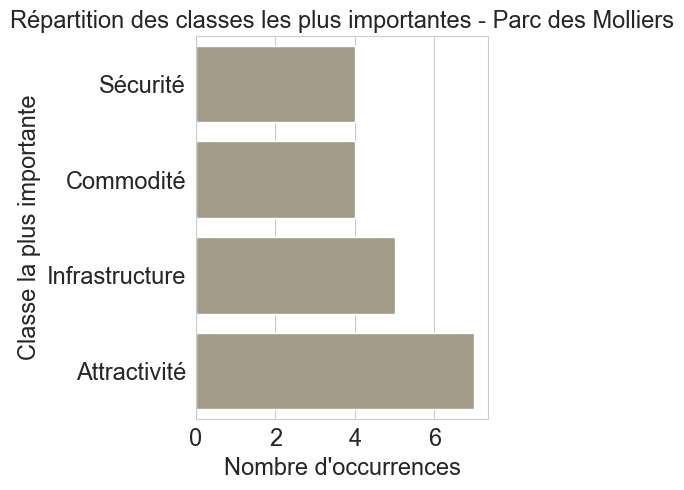

In [13]:
# Comptes les occurences dans df['Classe la plus importante'], certaines valeurs peuvent être séparées par des point virgules et faire un petit bar chart
plt.rcParams["font.family"] = "Arial"

class_counts = Counter()
for entry in df['Classe la plus importante'].dropna():
    classes = [cls.strip() for cls in entry.split(';')]
    class_counts.update(classes)
df_class_counts = pd.DataFrame.from_dict(class_counts, orient='index', columns=['Count']).reset_index()
df_class_counts = df_class_counts.rename(columns={'index': 'Classe la plus importante'})

# Sort by count for better readability
df_class_counts = df_class_counts.sort_values('Count', ascending=True)

#Faire un barplot horizontal de df_class_counts
plt.figure(figsize=(5, 5))
sns.barplot(data=df_class_counts, y='Classe la plus importante', x='Count', color='#A59E83')
plt.title(f"Répartition des classes les plus importantes - {site_to_plot}", fontsize=17)
plt.ylabel("Classe la plus importante", fontsize=17)
plt.xlabel("Nombre d'occurrences", fontsize=17)
plt.xticks(fontsize=17)
plt.yticks(fontsize=17)
plt.tight_layout()

# -------------------------------------------------------------
# OPTION EXPORT PNG 300 DPI TRANSPARENT
plt.savefig(f"../temp_/{site_to_plot}scores_moyens_attributs.png", dpi=300, transparent=True, bbox_inches='tight')
# --------------------------------------------------------------

## 👥 Échantillon

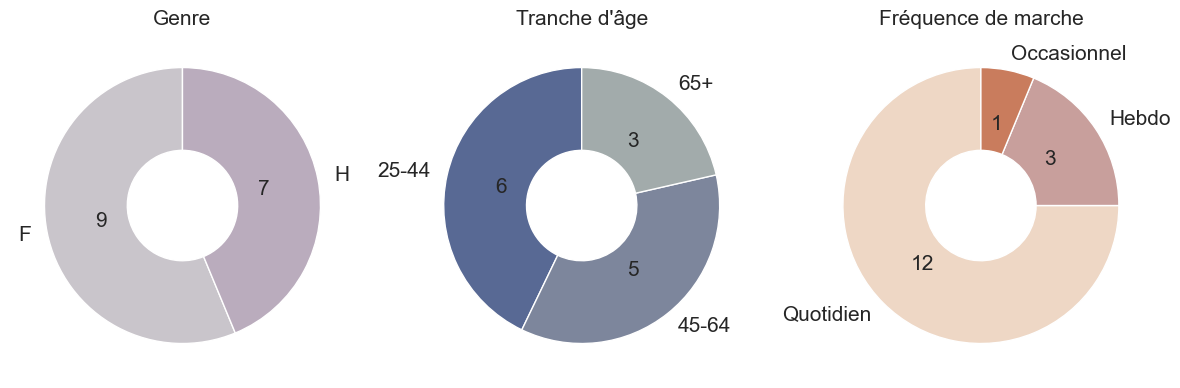

In [5]:
import matplotlib.pyplot as plt

# Police Arial
plt.rcParams["font.family"] = "Arial"
font_size = 15

# Données
genre_counts = df['genre'].value_counts()
age_counts = df['age_tranche'].value_counts()
freq_counts = df['frequence_marche'].value_counts()

# Ordres cohérents
age_order = ['25-44', '45-64', '65+']
age_counts = age_counts.reindex([a for a in age_order if a in age_counts.index])

freq_order = ['Quotidien', 'Hebdo', '1ère fois', 'Occasionnel']
freq_counts = freq_counts.reindex([f for f in freq_order if f in freq_counts.index])

# helper pour afficher les nombres (effectifs) dans les tranches
def make_autopct(values):
    def autopct(pct):
        total = sum(values)
        val = int(round(pct * total / 100.0))
        return f"{val}" if val > 0 else ""
    return autopct

# ================================
# PALETTES DIFFÉRENTES PAR PIE
# ================================
palette_genre = ["#c9c5cb", "#baacbd", "#b48eae"]             # tons doux
palette_age   = ["#586994", "#7d869c", "#a2abab"]              # neutres
palette_freq  = ["#eed7c5", "#c89f9c", "#c97c5d", "#b36a5e"]  # pastels chauds

fig, axes = plt.subplots(1, 3, figsize=(12, 4))

# common pie params
wedgeprops = dict(width=0.6, edgecolor='white')
startangle = 90

# --- Pie chart : Genre ---
axes[0].pie(
    genre_counts.values,
    labels=genre_counts.index,
    labeldistance=1.12,            # libellés hors du disque
    colors=palette_genre[:len(genre_counts)],
    autopct=make_autopct(genre_counts.values),
    pctdistance=0.6,               # position du chiffre à l'intérieur
    startangle=startangle,
    wedgeprops=wedgeprops,
    textprops={"fontsize": font_size},
)
axes[0].set_title("Genre", fontsize=font_size)

# --- Pie chart : Tranche d’âge ---
axes[1].pie(
    age_counts.values,
    labels=age_counts.index,
    labeldistance=1.12,
    colors=palette_age[:len(age_counts)],
    autopct=make_autopct(age_counts.values),
    pctdistance=0.6,
    startangle=startangle,
    wedgeprops=wedgeprops,
    textprops={"fontsize": font_size},
)
axes[1].set_title("Tranche d'âge", fontsize=font_size)

# --- Pie chart : Fréquence de marche ---
axes[2].pie(
    freq_counts.values,
    labels=freq_counts.index,
    labeldistance=1.12,
    colors=palette_freq[:len(freq_counts)],
    autopct=make_autopct(freq_counts.values),
    pctdistance=0.6,
    startangle=startangle,
    wedgeprops=wedgeprops,
    textprops={"fontsize": font_size},
)
axes[2].set_title("Fréquence de marche", fontsize=font_size)

# Ajustements et affichage
for ax in axes:
    ax.set(aspect='equal')

plt.tight_layout()
# -------------------------------------------------------------
# Export PNG haute qualité (option)
plt.savefig(f"../temp_/{site_to_plot}piecharts_trois_palettes_counts.png", dpi=300, transparent=True)
# -------------------------------------------------------------
plt.show()


## 📊 Scores par attribut

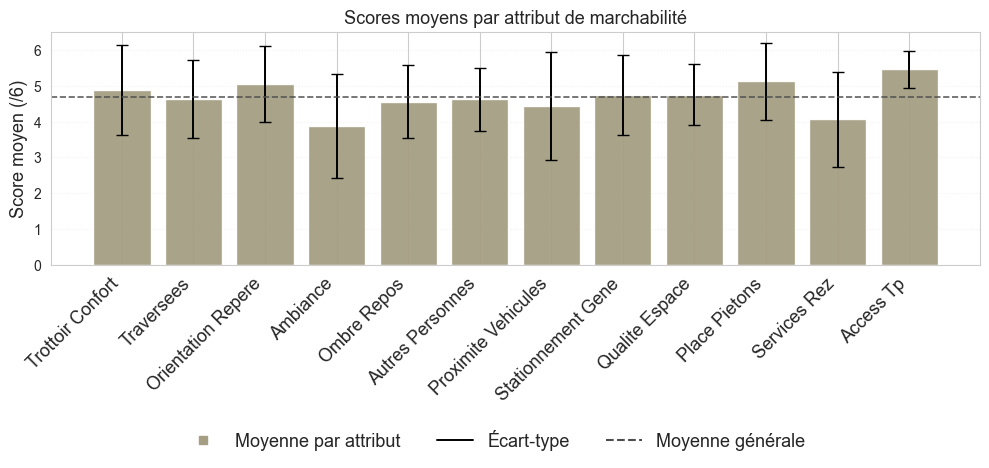

In [14]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
plt.rcParams["font.family"] = "Arial"
# Colonnes de scores
score_cols = [c for c in df.columns if c.endswith("_6")]
score_labels = [c.replace("_6", "").replace("_", " ").title() for c in score_cols]

# Moyennes et écarts-types
means = df[score_cols].mean().values
stds = df[score_cols].std().values

# Moyenne générale (tous attributs et répondant·es)
global_mean = np.nanmean(df[score_cols].values)

# Positions en X
x_pos = np.arange(len(score_labels))

# Palette minimaliste
color_bar = "#A59E83"   # vert principal
color_err = "black"     # écarts-types
color_global = "#4E4E4E"

fig, ax = plt.subplots(figsize=(10, 4.5))

# Barres avec écart-type
bars = ax.bar(
    x_pos,
    means,
    yerr=stds,
    capsize=4,
    color=color_bar,
    ecolor=color_err,
    alpha=0.95,
    error_kw={"elinewidth": 1.4}
)

# Ligne de moyenne générale
ax.axhline(
    global_mean,
    color=color_global,
    linestyle="--",
    linewidth=1.2,
    alpha=0.9
)

# Axes
ax.set_xticks(x_pos)
ax.set_xticklabels(score_labels, rotation=45, ha="right", fontsize=13)
upper_ylim = max(means + stds) + 0.3
ax.set_ylim(0, upper_ylim)
ax.set_ylabel("Score moyen (/6)", fontsize=13)
ax.set_title("Scores moyens par attribut de marchabilité", fontsize=13)
ax.grid(axis="y", alpha=0.25, linestyle=":")

# Légende à l'extérieur du plot
bar_handle = mlines.Line2D([], [], color=color_bar, marker="s", linestyle="none",
                            label="Moyenne par attribut")
err_handle = mlines.Line2D([], [], color=color_err, linewidth=1.4,
                            label="Écart-type")
global_handle = mlines.Line2D([], [], color=color_global, linestyle="--",
                              label="Moyenne générale")

fig.legend(
    handles=[bar_handle, err_handle, global_handle],
    loc="lower center",
    ncol=3,
    frameon=False,
    fontsize=13,
    bbox_to_anchor=(0.5, -0.05)
)

plt.tight_layout()

# Ajustement de l'espace inférieur pour la légende
plt.subplots_adjust(bottom=0.4)

# -------------------------------------------------------------
# OPTION EXPORT PNG 300 DPI TRANSPARENT
plt.savefig(f"../temp_/{site_to_plot}scores_moyens_attributs.png", dpi=300, transparent=True, bbox_inches='tight')
# -------------------------------------------------------------

plt.show()

In [7]:
df.columns

Index(['site', 'entretien_id', 'Description', 'genre', 'age_tranche',
       'accompagnement', 'frequence_marche', 'motif', 'trottoir_confort_6',
       'traversees_6', 'orientation_repere_6', 'ambiance_6', 'ombre_repos_6',
       'autres_personnes_6', 'proximite_vehicules_6', 'stationnement_gene_6',
       'qualite_espace_6', 'place_pietons_6', 'services_rez_6', 'access_tp_6',
       'Moyenne (calculée)', 'Evaluation generale (déclarée)',
       'Classe la plus importante', 'commentaire_libre', 'mots_cles_1',
       'mots_cles_2', 'mots_cles_3', 'Moyenne_calculee'],
      dtype='object')

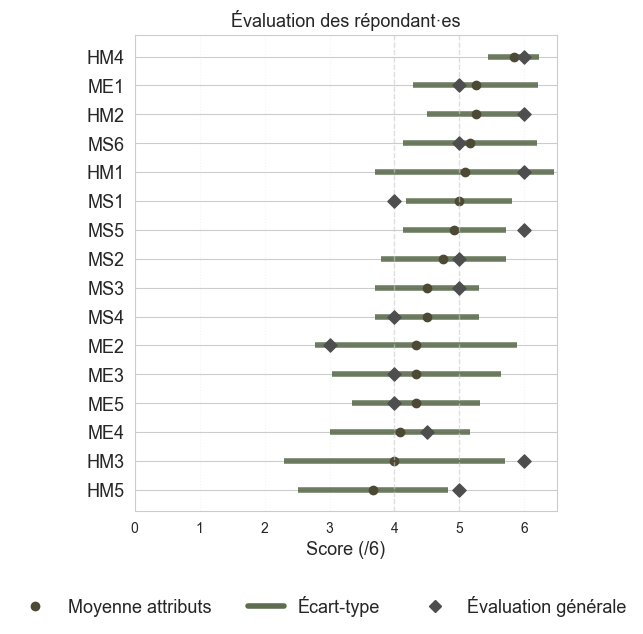

In [8]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.lines as mlines


plt.rcParams["font.family"] = "Arial"


# Colonnes de scores
score_cols = [c for c in df.columns if c.endswith("_6")]

# Moyenne et écart-type par répondant
df["score_moyen_participant"] = df[score_cols].mean(axis=1)
df["score_std_participant"] = df[score_cols].std(axis=1)

# Tri du meilleur au moins bon
order = df.sort_values("score_moyen_participant", ascending=False).reset_index(drop=True)
y_pos = np.arange(len(order))[::-1]

# Palette minimaliste
color_mean = "#4C4A34"    # sauge
color_std = "#5D6D4F"   # vert principal
color_eval = "#4E4E4E"      # gris foncé

# Figure
fig, ax = plt.subplots(figsize=(5, max(3.2, len(order) * 0.38)))  # encore un peu plus compact

# Intervalle (moyenne ± écart-type)
for yi, mean_val, std_val in zip(
    y_pos, order["score_moyen_participant"], order["score_std_participant"]
):
    ax.hlines(
        yi,
        mean_val - std_val,
        mean_val + std_val,
        color=color_std,
        linewidth=4,
        alpha=0.9,
    )
    ax.plot(mean_val, yi, "o", color=color_mean, markersize=6)

# Évaluation générale (diamant)
ax.scatter(
    order["Evaluation generale (déclarée)"],
    y_pos,
    marker="D",
    color=color_eval,
    s=45,
    zorder=5,
)

# Axe Y
ax.set_yticks(y_pos)
ax.set_yticklabels(order["entretien_id"], fontsize=13)

# Axe X
ax.set_xlim(0, 6.5)
ax.set_xlabel("Score (/6)", fontsize=13)
ax.set_title(
    "Évaluation des répondant·es",
    fontsize=13,
)
ax.grid(axis="x", alpha=0.2, linestyle=":")

# Lignes de référence
ax.axvline(4, color="#CCCCCC", linestyle="--", linewidth=1, alpha=0.6)
ax.axvline(5, color="#CCCCCC", linestyle="--", linewidth=1, alpha=0.6)

# Légende minimaliste
mean_handle = mlines.Line2D(
    [], [], color=color_mean, marker="o", linestyle="none", label="Moyenne attributs"
)
std_handle = mlines.Line2D(
    [], [], color=color_std, linewidth=4, label="Écart-type"
)
eval_handle = mlines.Line2D(
    [], [], color=color_eval, marker="D", linestyle="none", label="Évaluation générale"
)

fig.legend(
    handles=[mean_handle, std_handle, eval_handle],
    loc="lower center",
    ncol=3,
    frameon=False,
    fontsize=13,
    bbox_to_anchor=(0.5, -0.05),
)

plt.tight_layout()

# Ajustement de l'espace inférieur pour la légende
plt.subplots_adjust(bottom=0.15)

# -------------------------------------------------------------
# OPTION EXPORT PNG SANS FOND EN 300 DPI (décommenter ci-dessous)
#plt.savefig("../temp_/scores_par_repondant.png", dpi=300, transparent=True, bbox_inches='tight')
# -------------------------------------------------------------

plt.show()

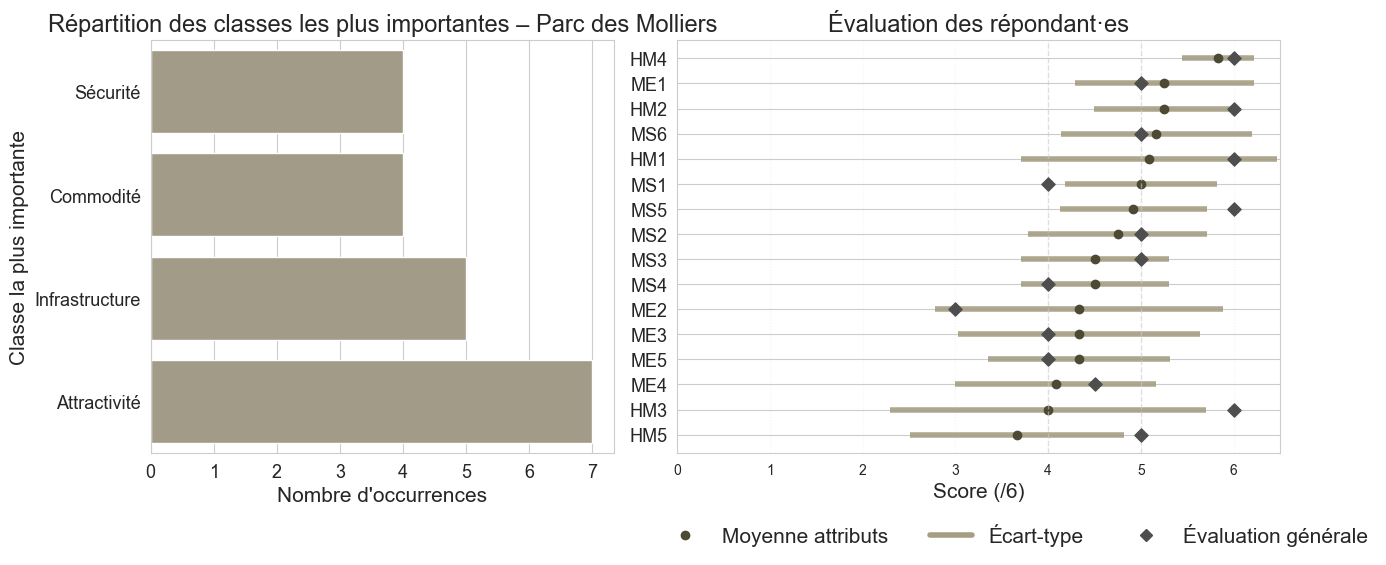

In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.lines as mlines
from collections import Counter

plt.rcParams["font.family"] = "Arial"

# ---------------------------------------------------------------------
# PARAMÈTRES D'UNIFORMISATION
# ---------------------------------------------------------------------
TITLE_SIZE = 17
LABEL_SIZE = 15
TICK_SIZE = 13

# ---------------------------------------------------------------------
# 1. PREMIER GRAPHIQUE : Comptage des classes
# ---------------------------------------------------------------------

class_counts = Counter()
for entry in df['Classe la plus importante'].dropna():
    classes = [cls.strip() for cls in entry.split(';')]
    class_counts.update(classes)

df_class_counts = (
    pd.DataFrame
    .from_dict(class_counts, orient='index', columns=['Count'])
    .reset_index()
    .rename(columns={'index': 'Classe la plus importante'})
    .sort_values('Count', ascending=True)
)

# ---------------------------------------------------------------------
# 2. SECOND GRAPHIQUE : Scores moyens par répondant·e
# ---------------------------------------------------------------------

score_cols = [c for c in df.columns if c.endswith("_6")]

df["score_moyen_participant"] = df[score_cols].mean(axis=1)
df["score_std_participant"] = df[score_cols].std(axis=1)

order = df.sort_values("score_moyen_participant", ascending=False).reset_index(drop=True)
y_pos = np.arange(len(order))[::-1]

color_mean = "#4C4A34"
color_std = "#A59E83"
color_eval = "#4E4E4E"

# ---------------------------------------------------------------------
# FIGURE UNIQUE
# ---------------------------------------------------------------------

fig, axes = plt.subplots(
    1, 2,
    figsize=(13, max(5, len(order) * 0.35)),
    gridspec_kw={"width_ratios": [1, 1.3]}
)

ax1, ax2 = axes

# ---------------------------------------------------------------------
# GRAPHIQUE 1 · BARPLOT HORIZONTAL
# ---------------------------------------------------------------------

sns.barplot(
    data=df_class_counts,
    y='Classe la plus importante',
    x='Count',
    color='#A59E83',
    ax=ax1
)

ax1.set_title(f"Répartition des classes les plus importantes – {site_to_plot}", fontsize=TITLE_SIZE)
ax1.set_xlabel("Nombre d'occurrences", fontsize=LABEL_SIZE)
ax1.set_ylabel("Classe la plus importante", fontsize=LABEL_SIZE)
ax1.tick_params(axis='both', labelsize=TICK_SIZE)

# ---------------------------------------------------------------------
# GRAPHIQUE 2 · SCORE MOYEN ± ÉCART-TYPE + ÉVALUATION GÉNÉRALE
# ---------------------------------------------------------------------

for yi, mean_val, std_val in zip(
    y_pos, order["score_moyen_participant"], order["score_std_participant"]
):
    ax2.hlines(yi, mean_val - std_val, mean_val + std_val,
               color=color_std, linewidth=4, alpha=0.9)
    ax2.plot(mean_val, yi, "o", color=color_mean, markersize=6)

ax2.scatter(
    order["Evaluation generale (déclarée)"],
    y_pos,
    marker="D",
    color=color_eval,
    s=45,
    zorder=5,
)

ax2.set_yticks(y_pos)
ax2.set_yticklabels(order["entretien_id"], fontsize=TICK_SIZE)

ax2.set_xlim(0, 6.5)
ax2.set_xlabel("Score (/6)", fontsize=LABEL_SIZE)
ax2.set_title("Évaluation des répondant·es", fontsize=TITLE_SIZE)
ax2.grid(axis="x", alpha=0.2, linestyle=":")

ax2.axvline(4, color="#CCCCCC", linestyle="--", linewidth=1, alpha=0.6)
ax2.axvline(5, color="#CCCCCC", linestyle="--", linewidth=1, alpha=0.6)

mean_handle = mlines.Line2D([], [], color=color_mean, marker="o", linestyle="none", label="Moyenne attributs")
std_handle = mlines.Line2D([], [], color=color_std, linewidth=4, label="Écart-type")
eval_handle = mlines.Line2D([], [], color=color_eval, marker="D", linestyle="none", label="Évaluation générale")

fig.legend(
    handles=[mean_handle, std_handle, eval_handle],
    loc="lower left",
    ncol=3,
    frameon=False,
    fontsize= LABEL_SIZE,
    bbox_to_anchor=(0.5, -0.02),
)

plt.tight_layout()
plt.subplots_adjust(bottom=0.18)

# ---------------------------------------------------------------------
# EXPORT UNIQUE
# ---------------------------------------------------------------------
plt.savefig(f"../temp_/{site_to_plot}scores_classes.png",
            dpi=300, transparent=True, bbox_inches='tight')

plt.show()

## 🔍 Comparaison par profil démographique

/var/folders/gh/bcpf72g151g22zg7mqv0s2qw0000gn/T/ipykernel_55628/38559891.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_genre, x='genre', y='score_moyen_participant', ax=axes[0], palette=['#FF6B9D', '#4D96FF'])
/var/folders/gh/bcpf72g151g22zg7mqv0s2qw0000gn/T/ipykernel_55628/38559891.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_age.sort_values('age_tranche'), x='age_tranche', y='score_moyen_participant',
/var/folders/gh/bcpf72g151g22zg7mqv0s2qw0000gn/T/ipykernel_55628/38559891.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effec

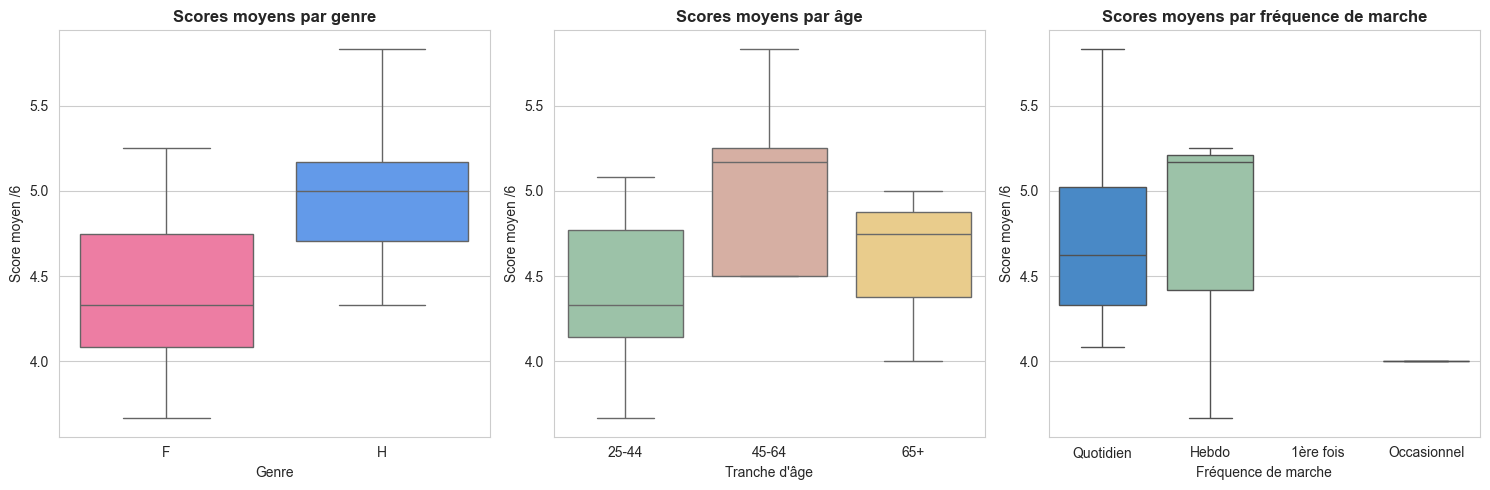

In [10]:
score_cols = [c for c in df.columns if c.endswith('_6')]
df['score_moyen_participant'] = df[score_cols].mean(axis=1)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

df_genre = df[df['genre'].notna()]
if len(df_genre) > 0:
    sns.boxplot(data=df_genre, x='genre', y='score_moyen_participant', ax=axes[0], palette=['#FF6B9D', '#4D96FF'])
    axes[0].set_title('Scores moyens par genre', fontweight='bold')
    axes[0].set_ylabel('Score moyen /6')
    axes[0].set_xlabel('Genre')

df_age = df[df['age_tranche'].notna()]
if len(df_age) > 0:
    age_order = ['25-44', '45-64', '65+']
    df_age['age_tranche'] = pd.Categorical(df_age['age_tranche'], categories=age_order, ordered=True)
    sns.boxplot(data=df_age.sort_values('age_tranche'), x='age_tranche', y='score_moyen_participant', 
                ax=axes[1], palette=['#96C8A6', '#DFAB9A', '#F8D27D'])
    axes[1].set_title('Scores moyens par âge', fontweight='bold')
    axes[1].set_ylabel('Score moyen /6')
    axes[1].set_xlabel('Tranche d\'âge')

df_freq = df[df['frequence_marche'].notna()]
if len(df_freq) > 0:
    freq_order = ['Quotidien', 'Hebdo', '1ère fois', 'Occasionnel']
    df_freq['frequence_marche'] = pd.Categorical(df_freq['frequence_marche'], categories=freq_order, ordered=True)
    sns.boxplot(data=df_freq.sort_values('frequence_marche'), x='frequence_marche', y='score_moyen_participant', 
                ax=axes[2], palette=['#3489DB', '#96C8A6', '#DFAB9A', '#F8D27D'])
    axes[2].set_title('Scores moyens par fréquence de marche', fontweight='bold')
    axes[2].set_ylabel('Score moyen /6')
    axes[2].set_xlabel('Fréquence de marche')

plt.tight_layout()
plt.show()

## ☁️ Mots-clés émergents

In [11]:
try:
    from wordcloud import WordCloud
    import spacy
except ImportError:
    print('Installation des dépendances...')
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', 'wordcloud', 'spacy'])
    from wordcloud import WordCloud
    import spacy

try:
    nlp = spacy.load('fr_core_news_sm')
except:
    print('Téléchargement du modèle spaCy français...')
    subprocess.check_call([sys.executable, '-m', 'spacy', 'download', '-q', 'fr_core_news_sm'])
    nlp = spacy.load('fr_core_news_sm')

all_texts = []
for text in df['commentaires_libres'].dropna():
    if isinstance(text, str):
        all_texts.append(text)
for text in df['mots_cles'].dropna():
    if isinstance(text, str):
        all_texts.append(text)

combined_text = ' '.join(all_texts).lower()

doc = nlp(combined_text)
lemmas = []
for token in doc:
    if (not token.is_stop and len(token.text) > 2 and token.pos_ in ['NOUN', 'ADJ', 'VERB']):
        lemmas.append(token.lemma_)

lemmatized_text = ' '.join(lemmas)
print(f'✓ {len(lemmas)} termes-clés extraits')

KeyError: 'commentaires_libres'

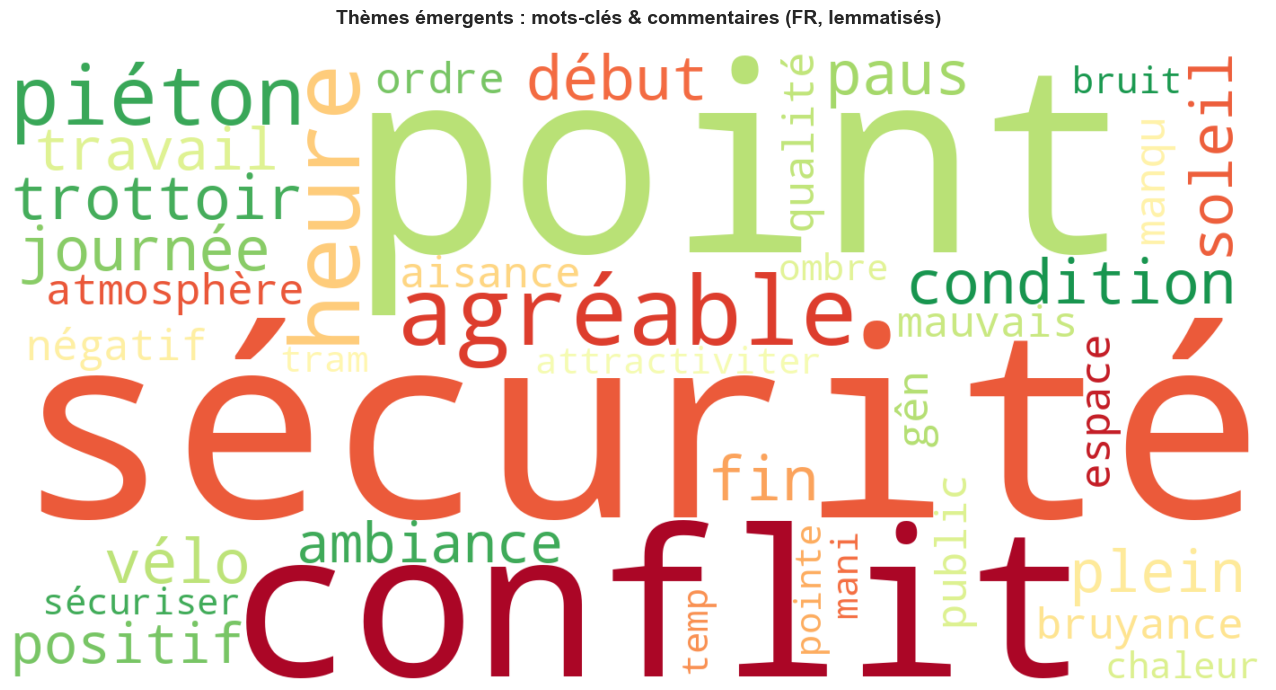


🔤 Top 15 termes:
  sécurité            :   3x
  point               :   3x
  conflit             :   2x
  agréable            :   2x
  heure               :   2x
  piéton              :   2x
  trottoir            :   1x
  vélo                :   1x
  condition           :   1x
  début               :   1x
  fin                 :   1x
  journée             :   1x
  paus                :   1x
  travail             :   1x
  plein               :   1x


In [ ]:
wordcloud = WordCloud(
    width=1400,
    height=700,
    background_color='white',
    colormap='RdYlGn',
    relative_scaling=0.5,
    min_font_size=14,
    max_words=80,
    prefer_horizontal=0.7
).generate(lemmatized_text)

fig, ax = plt.subplots(figsize=(15, 7))
ax.imshow(wordcloud, interpolation='bilinear')
ax.axis('off')
ax.set_title('Thèmes émergents : mots-clés & commentaires (FR, lemmatisés)', 
             fontweight='bold', fontsize=14, pad=20)
plt.tight_layout()
plt.show()

print('\n🔤 Top 15 termes:')
freqs = Counter(lemmatized_text.split())
for word, count in freqs.most_common(15):
    print(f'  {word:20s}: {count:3d}x')

## 🔥 Heatmap : Vue d'ensemble des scores

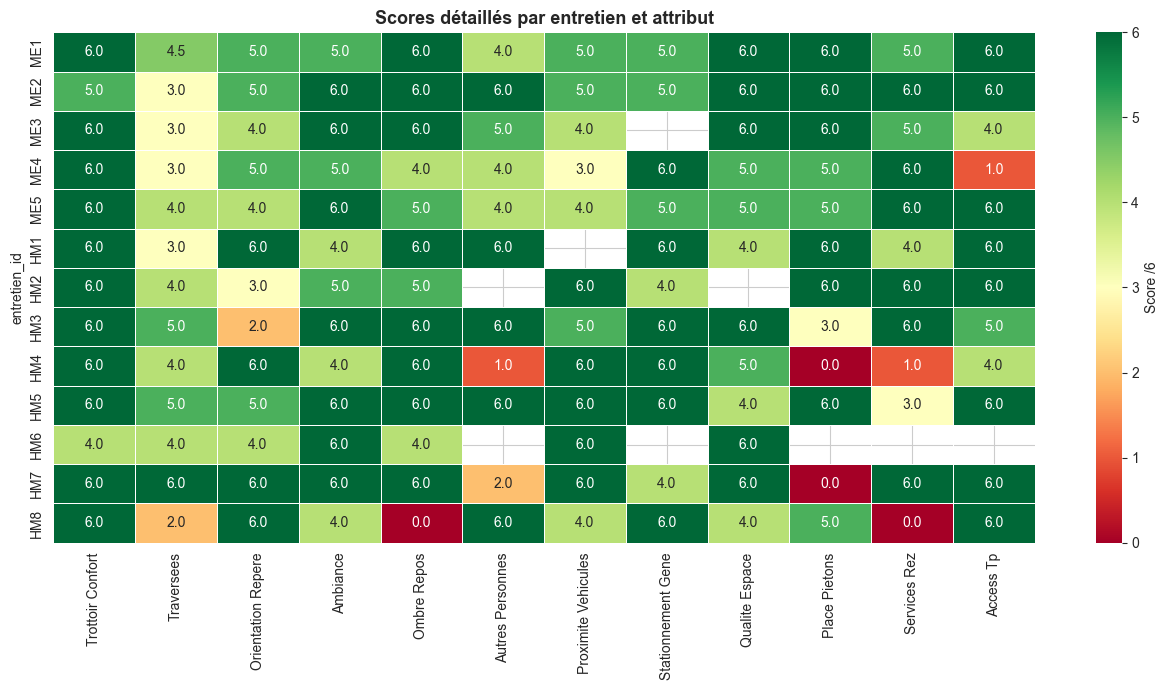

In [ ]:
score_cols = [c for c in df.columns if c.endswith('_6')]
score_matrix = df[['entretien_id'] + score_cols].set_index('entretien_id')
score_matrix.columns = [c.replace('_6', '').replace('_', ' ').title() for c in score_cols]

fig, ax = plt.subplots(figsize=(13, 7))
sns.heatmap(score_matrix, annot=True, fmt='.1f', cmap='RdYlGn', 
            center=3, vmin=0, vmax=6, cbar_kws={'label': 'Score /6'}, 
            linewidths=0.5, ax=ax)
ax.set_title('Scores détaillés par entretien et attribut', fontweight='bold', fontsize=13)
ax.set_xlabel('')
plt.tight_layout()
plt.show()